In [ ]:
import os
path = "/mnt/d/MSAIM/trimister-3 msaiml/Computer_vision/Computer_vision_practical/shapes_img"
file_name = []
for files in os.walk(path):
    for file in files:
        file_name.append(file)



['pexels-ekaterina-bolovtsova-7307619.jpg', 'pexels-ekaterina-bolovtsova-7307691.jpg', 'pexels-lamfy-ts-1514477864-27967976.jpg', 'pexels-mikhail-nilov-7827956.jpg']


Displaying image 1: pexels-ekaterina-bolovtsova-7307619.jpg
Displaying image 2: pexels-ekaterina-bolovtsova-7307691.jpg
Displaying image 3: pexels-lamfy-ts-1514477864-27967976.jpg
Displaying image 4: pexels-mikhail-nilov-7827956.jpg


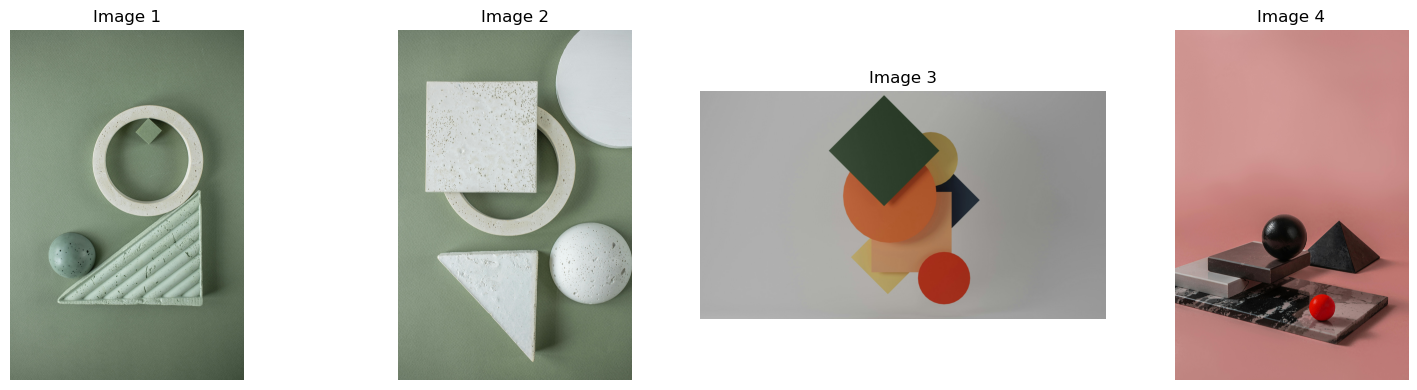

In [25]:
import matplotlib.pyplot as plt 
import cv2
import os

count = 1
images = []

# Assuming file_name[2] contains list of image file names
# and path is defined somewhere
num_images = len(file_name[2])
plt.figure(figsize=(4 * num_images, 4))  # Adjust the figure size based on number of images

for i, image_name in enumerate(file_name[2]):
    img = cv2.imread(os.path.join(path, image_name)) 
    images.append(img)
    
    if img is not None:
        print(f"Displaying image {count}: {image_name}")
        plt.subplot(1, num_images, count)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Image {count}")
        plt.axis('off')
    count += 1

plt.tight_layout()
plt.show()


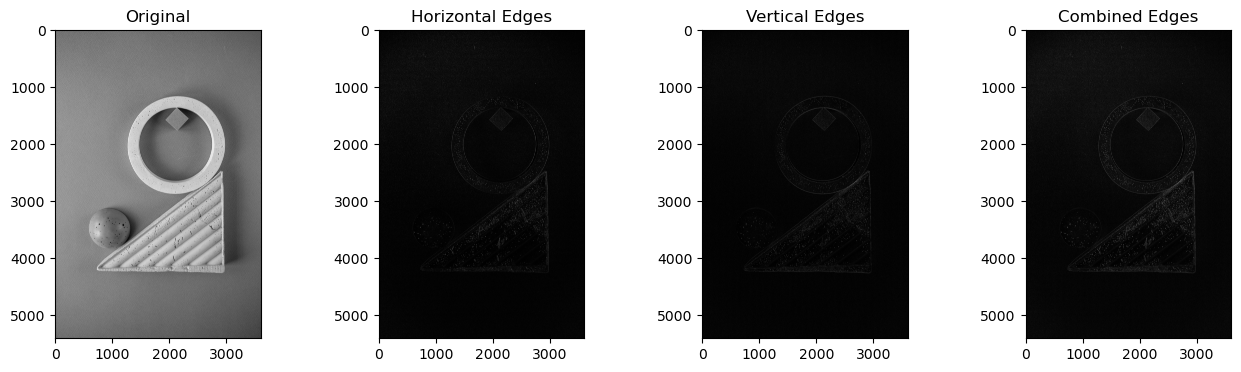

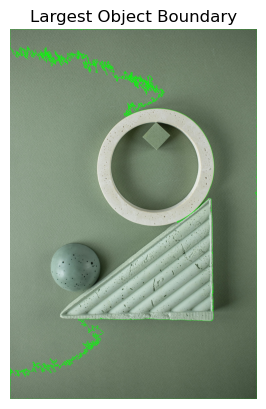

Chain Code: [0, 0, 0, 1, 0, 0, 3, 0, 0, 1, 3, 0, 0, 1, 0, 3, 2, 3, 0, 0, 0, 0, 1, 0, 0, 1, 3, 0, 3, 2, 3, 2, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 3]...
Aspect Ratio: 0.67, Extent: 0.43, Solidity: 0.43
Classified Shape: Unidentified


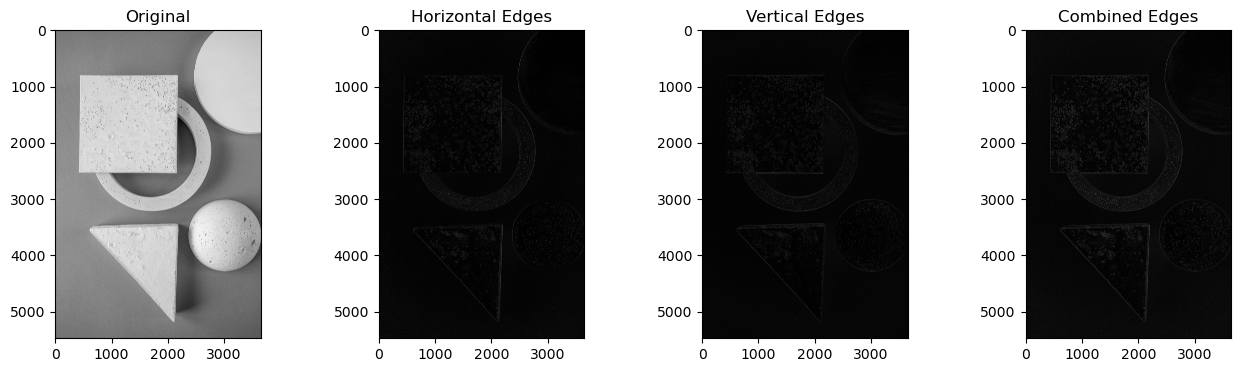

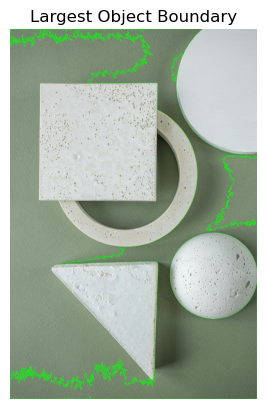

Chain Code: [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 2, 3, 0, 2, 2, 2, 1, 3, 2, 2, 0, 1, 0, 0, 3, 0, 0, 3, 0, 0, 0, 0, 1, 1, 2, 1, 0, 0, 3, 0, 3, 2, 3, 0, 0, 1, 3, 0, 1]...
Aspect Ratio: 0.67, Extent: 0.25, Solidity: 0.26
Classified Shape: Unidentified


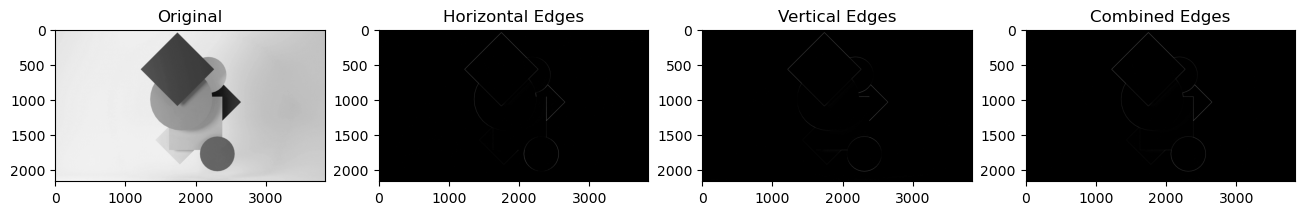

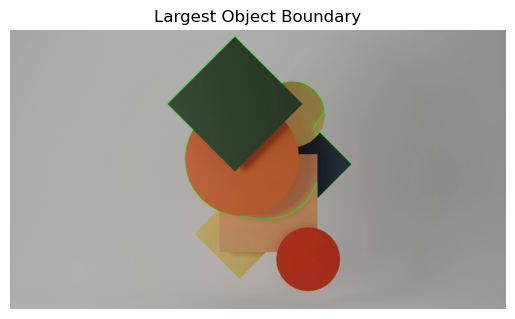

Chain Code: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
Aspect Ratio: 1.01, Extent: 0.60, Solidity: 0.92
Classified Shape: Square


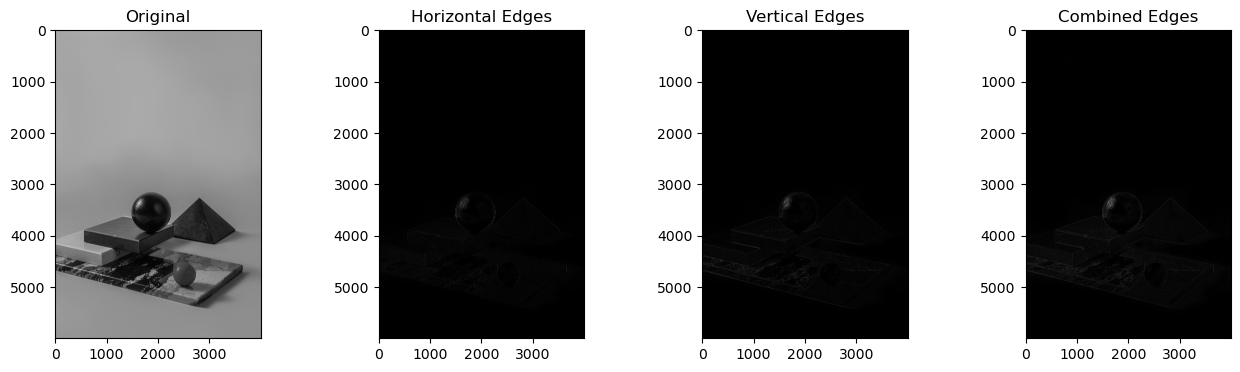

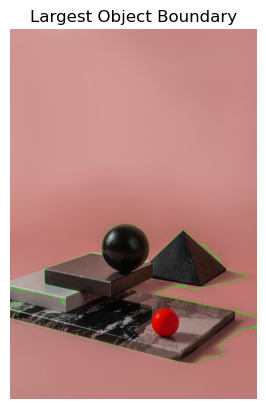

Chain Code: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3]...
Aspect Ratio: 1.76, Extent: 0.54, Solidity: 0.80
Classified Shape: Triangle


In [26]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

count = 1
images = []
file_list = file_name[2]

for i, image_name in enumerate(file_list):
    img = cv2.imread(os.path.join(path, image_name))
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    images.append(img)
    
    # Edge Detection
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
    sobel_xy = cv2.magnitude(sobel_x, sobel_y)

    # Display edges
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original')

    plt.subplot(1, 4, 2)
    plt.imshow(np.abs(sobel_x), cmap='gray')
    plt.title('Horizontal Edges')

    plt.subplot(1, 4, 3)
    plt.imshow(np.abs(sobel_y), cmap='gray')
    plt.title('Vertical Edges')

    plt.subplot(1, 4, 4)
    plt.imshow(np.abs(sobel_xy), cmap='gray')
    plt.title('Combined Edges')
    plt.show()

    # Thresholding & Contour detection
    ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = max(contours, key=cv2.contourArea)

    # Draw largest boundary
    img_copy = img.copy()
    cv2.drawContours(img_copy, [largest_contour], -1, (0, 255, 0), 2)
    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    plt.title("Largest Object Boundary")
    plt.axis('off')
    plt.show()

    # 4-directional chain code (0:→, 1:↓, 2:←, 3:↑)
    directions = {(-1, 0): 3, (0, -1): 2, (1, 0): 1, (0, 1): 0}
    contour = largest_contour.squeeze()
    chain_code = []
    for i in range(1, len(contour)):
        dy = contour[i][1] - contour[i-1][1]
        dx = contour[i][0] - contour[i-1][0]
        step = (np.sign(dx), np.sign(dy))
        if step in directions:
            chain_code.append(directions[step])
    print(f"Chain Code: {chain_code[:50]}...")  # Print first 50 steps

    # Shape descriptor
    x, y, w, h = cv2.boundingRect(largest_contour)
    aspect_ratio = float(w)/h
    area = cv2.contourArea(largest_contour)
    rect_area = w * h
    extent = float(area) / rect_area
    hull = cv2.convexHull(largest_contour)
    hull_area = cv2.contourArea(hull)
    solidity = float(area)/hull_area

    print(f"Aspect Ratio: {aspect_ratio:.2f}, Extent: {extent:.2f}, Solidity: {solidity:.2f}")

    # Simple Shape Classification
    shape = "Unidentified"
    if solidity > 0.9:
        if 0.9 < aspect_ratio < 1.1:
            shape = "Square"
        else:
            shape = "Rectangle"
    elif len(largest_contour) >= 3:
        approx = cv2.approxPolyDP(largest_contour, 0.04 * cv2.arcLength(largest_contour, True), True)
        if len(approx) == 3:
            shape = "Triangle"
        elif len(approx) > 8:
            shape = "Circle"
    print(f"Classified Shape: {shape}")

    count += 1
